# Split single-cell reads

This notebook profile the threshold for the splitting single-cell reads procedure.

Take 5 runs of K562 cells, for example.

In [30]:
from collections import defaultdict
import gzip, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
info = pd.read_csv("../../../1_NanoNASCseq/reports/NanoNASCseq_Summary.csv")
runs = [
    "20220719_K562_1", 
    "20220719_K562_2", 
    "20220719_K562_3", 
    "20220719_K562_4", 
    "20220729_K562_1", 
    "20220729_K562_2",
]

## 1. Distribution of edit distance (barplot)

In [48]:
def stat_barcode_edit_distance(infile, outfile):
    if os.path.exists(outfile):
        print("%s exists!" % outfile)
        return None
        
    d = pd.read_csv(infile)
    counter = defaultdict(int)
    for ed1, ed2, count in d[["ED1", "ED2", "Count"]].values:
        if ed1 != -1:
            counter[ed1] += count
            counter[ed2] += count
    rows = []
    for ed, count in sorted(counter.items()):
        rows.append([ed, count])
    m = pd.DataFrame(rows, columns=["ED", "Count"])
    m.to_csv(outfile, index=False)
        
for run in runs:
    infile = "../../../1_NanoNASCseq/results/2_demux/2_fbilr/%s.stats.csv.gz" % run
    outfile = "results/barcode_edit_distance/%s.csv" % run
    stat_barcode_edit_distance(infile, outfile)

results/barcode_edit_distance/20220719_K562_1.csv exists!
results/barcode_edit_distance/20220719_K562_2.csv exists!
results/barcode_edit_distance/20220719_K562_3.csv exists!
results/barcode_edit_distance/20220719_K562_4.csv exists!
results/barcode_edit_distance/20220729_K562_1.csv exists!
results/barcode_edit_distance/20220729_K562_2.csv exists!


In [82]:
array = []
max_ed = 7
for run in runs:
    d = pd.read_csv("results/barcode_edit_distance/%s.csv" % run)
    counter = defaultdict(int)
    for ed, count in d[["ED", "Count"]].values:
        counter[min(ed, max_ed)] += count
    array.append(counter)
m = pd.DataFrame(array, index=pd.Index(runs, name="Run"))
m = m.divide(m.sum(axis=1), axis=0)
m = pd.DataFrame({"Mean": m.mean(), "Std": m.std(), "Size": len(runs)})
m.index = pd.Index(["0", "1", "2", "3", "4", "5", "6", "ge7"], name="ED")
m.to_csv("results/barcode_edit_distance.stats.csv")

In [89]:
m = pd.read_csv("results/barcode_edit_distance.stats.csv", index_col=0)
m

,Mean,Std,Size
ED,,,
0,0.667529,0.030892,6
1,0.078499,0.008323,6
2,0.050294,0.005182,6
3,0.035891,0.003988,6
4,0.025887,0.002661,6
5,0.021288,0.001619,6
6,0.043540,0.007786,6
ge7,0.077072,0.009180,6


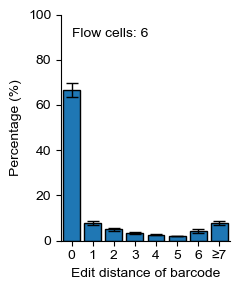

In [92]:
xs = np.arange(len(m))
plt.figure(figsize=(2.5, 3))
plt.bar(xs, m["Mean"]*100, yerr=m["Std"]*100, lw=1, capsize=4, width=0.8, color="C0", edgecolor="black", error_kw={"lw": 1})
plt.text(0, 90, "Flow cells: %d" % m["Size"].values[0])
plt.xlim(min(xs) - 0.5, max(xs) + 0.5)
plt.ylim(0, 100)
plt.xticks(xs, [str(s).replace("ge", "≥") for s in m.index])
plt.xlabel("Edit distance of barcode")
plt.ylabel("Percentage (%)")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("figures/barcode_edit_distance.bar.pdf")
plt.show()
plt.close()

## 2. Pattern of barcode direction and location (barplot)

In [93]:
def stat_barcode_direction_location_combination(infile, outfile):
    if os.path.exists(outfile):
        print("%s exists!" % outfile)
        return None
        
    d = pd.read_csv(infile)
    counter = defaultdict(int)
    for bar1, direct1, loc1, ed1, bar2, direct2, loc2, ed2, count in d.values:
        if ed1 != -1:
            counter[(ed1, direct1, loc1)] += count
            counter[(ed2, direct2, loc2)] += count
    rows = []
    for (ed, direct, loc), count in sorted(counter.items()):
        rows.append([ed, direct, loc, count])
    m = pd.DataFrame(rows, columns=["ED", "Direction", "Location", "Count"])
    m.to_csv(outfile, index=False)
    
for run in runs:
    infile = "../../../1_NanoNASCseq/results/2_demux/2_fbilr/%s.stats.csv.gz" % run
    outfile = "results/barcode_direction_location_combination/%s.csv" % run
    stat_barcode_direction_location_combination(infile, outfile)

--------------------------------------------------------------------------------
ED: 0
                       FH        RH        FT        RT
Run                                                    
20220719_K562_1  0.521940  0.000067  0.000304  0.477689
20220719_K562_2  0.517241  0.000192  0.001316  0.481251
20220719_K562_3  0.514624  0.000100  0.000378  0.484898
20220719_K562_4  0.520198  0.000103  0.000305  0.479393
20220729_K562_1  0.520644  0.000095  0.000429  0.478832
20220729_K562_2  0.536650  0.000008  0.000099  0.463242
Mean: [5.21883003e+01 9.42079766e-03 4.71985825e-02 4.77550803e+01]
Std: [0.77028207 0.00595873 0.04283178 0.74491862]
--------------------------------------------------------------------------------
ED: 1
                       FH        RH        FT        RT
Run                                                    
20220719_K562_1  0.509188  0.000062  0.000277  0.490474
20220719_K562_2  0.529113  0.000179  0.001264  0.469445
20220719_K562_3  0.492396  0.000088

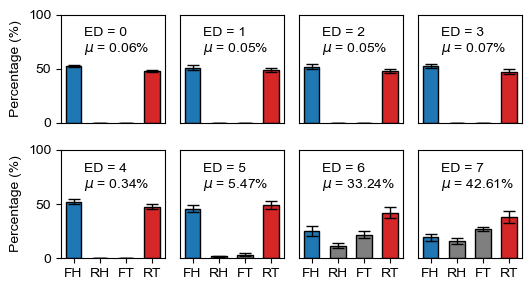

In [97]:
def get_metadata(ed):
    rows = []
    for run in runs:
        d = pd.read_csv("results/barcode_direction_location_combination/%s.csv" % run)
        d = d[d["ED"] == ed]
        fh = d[(d["Direction"] == "F") & (d["Location"] == "H")]["Count"].sum()
        rh = d[(d["Direction"] == "R") & (d["Location"] == "H")]["Count"].sum()
        ft = d[(d["Direction"] == "F") & (d["Location"] == "T")]["Count"].sum()
        rt = d[(d["Direction"] == "R") & (d["Location"] == "T")]["Count"].sum()
        rows.append([fh, rh, ft, rt])
    m = pd.DataFrame(rows, columns=["FH", "RH", "FT", "RT"], index=pd.Index(runs, name="Run"))
    m = m.divide(m.sum(axis=1), axis=0)
    return m

nrow, ncol = 2, 4
fig, axs = plt.subplots(nrow, ncol, figsize=(5.5, 3))
for ed in np.arange(ncol * nrow):
    print("-" * 80)
    print("ED:", ed)
    m = get_metadata(ed)
    print(m)
    ys = m.mean(axis=0) * 100
    yerr = m.std(axis=0) * 100
    print("Mean:", ys.values)
    print("Std:", yerr.values)
    xs = np.arange(4)
    colors = ["C0", "C7", "C7", "C3"]
    
    i1 = int(ed / ncol)
    i2 = ed % ncol
    ax = axs[i1][i2]
    plt.sca(ax)
    plt.bar(xs, ys, yerr=yerr, error_kw={"lw": 1, "capsize": 4}, color=colors, edgecolor="black", width=0.6)
    plt.ylim(0, 100)
    if i1 == 0:
        plt.xticks([])
    else:
        plt.xticks(xs, ["FH", "RH", "FT", "RT"])
    if i2 == 0:
        plt.ylabel("Percentage (%)")
    else:
        plt.yticks([])
    noise = 100 - (ys[0] + ys[3])
    x = 0.4
    plt.text(x, 80, "ED = %d" % ed)
    plt.text(x, 65, "$\mu$ = %.2f%%" % noise)
    plt.tight_layout(w_pad=0.5)
plt.savefig("figures/barcode_direction_location_combination.bar.pdf")
plt.show()
plt.close()

## 3. Profiling of dual-barcode (heatmap)

In [110]:
def stat_dual_barcode_edit_distance(infile, outfile):
    if os.path.exists(outfile):
        print("%s exists!" % outfile)
        return None
        
    counter = defaultdict(int)
    d = pd.read_csv(infile)
    for ed1, ed2, count in d[["ED1", "ED2", "Count"]].values:
        if ed1 == -1 or ed2 == -1:
            continue
        counter[(ed1, ed2)] += count

    with open(outfile, "w+") as fw:
        fw.write("ED1,ED2,Count\n")
        for (ed1, ed2), count in sorted(counter.items()):
            fw.write(",".join(map(str, [ed1, ed2, count])) + "\n")

for run in runs:
    infile = "../../../1_NanoNASCseq/results/2_demux/2_fbilr/%s.stats.csv.gz" % run
    outfile = "results/dual_barcode_edit_distance/%s.csv" % run
    stat_dual_barcode_edit_distance(infile, outfile)

results/dual_barcode_edit_distance/20220719_K562_1.csv exists!
results/dual_barcode_edit_distance/20220719_K562_2.csv exists!
results/dual_barcode_edit_distance/20220719_K562_3.csv exists!
results/dual_barcode_edit_distance/20220719_K562_4.csv exists!
results/dual_barcode_edit_distance/20220729_K562_1.csv exists!
results/dual_barcode_edit_distance/20220729_K562_2.csv exists!


In [114]:
array = []
for run in runs:
    m = np.zeros((6, 6), dtype=int)
    d = pd.read_csv("results/dual_barcode_edit_distance/%s.csv" % run)
    for ed1, ed2, count in d[["ED1", "ED2", "Count"]].values:
        m[int(min(ed1, 11)/2)][int(min(ed2, 11)/2)] += int(count)
    m = pd.DataFrame(m)
    m = m * 100 / m.sum().sum()
    m.columns = ["0-1", "2-3", "4-5", "6-7", "8-9", "≥10"]
    m.index = ["0-1", "2-3", "4-5", "6-7", "8-9", "≥10"]
    array.append(m)
    # break
m = sum(array) / len(array)
m.to_csv("results/dual_barcode_edit_distance.stats.csv")

In [117]:
m = pd.read_csv("results/dual_barcode_edit_distance.stats.csv", index_col=0)
m = m[::-1]
m

,0-1,2-3,4-5,6-7,8-9,≥10
≥10,0.000999,0.000135,0.000071,0.000186,0.000024,0.000026
8-9,0.274184,0.035274,0.022156,0.132978,0.015100,0.000057
6-7,4.620294,0.739113,0.475995,2.098622,0.125376,0.000417
4-5,2.945256,0.585314,0.360482,0.805658,0.040158,0.000182
2-3,5.888070,1.020300,0.604649,1.413688,0.071453,0.000322
0-1,57.753175,5.858370,3.234782,10.338364,0.535812,0.002957


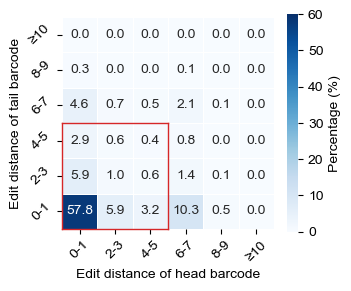

In [119]:
plt.figure(figsize=(3.6, 3))
sns.heatmap(m, annot=True, fmt=".1f", cmap="Blues", lw=0.5, vmin=0, vmax=60,
            square=True, cbar_kws={"label": "Percentage (%)"})
if True:
    plt.plot([0, 3], [3, 3], color="C3", lw=1, clip_on=False)
    plt.plot([0, 3], [6, 6], color="C3", lw=1, clip_on=False)
    plt.plot([0, 0], [3, 6], color="C3", lw=1, clip_on=False)
    plt.plot([3, 3], [3, 6], color="C3", lw=1, clip_on=False)
    
plt.xlabel("Edit distance of head barcode")
plt.ylabel("Edit distance of tail barcode")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.savefig("figures/dual_barcode_edit_distance.heatmap.pdf")
plt.show()
plt.close()

## 4. Proportion of assigned cell reads (pie)

In [124]:
array = []
for run in runs:
    path = "../../../1_NanoNASCseq/results/2_demux/3_splitted/%s/stats.tsv" % run
    array.append(pd.read_csv(path, sep="\t", index_col=0))
d = pd.concat(array)
columns = ["TooShort", "Unknown", "Conflict", "Assigned"]
columns = ["TooShort", "Unknown", "Conflict", "Assigned"]
d = pd.concat([d[c] / d["Total"] for c in columns], axis=1)
d.columns = columns
d.to_csv("results/cell_reads_proportion.stats.csv")
d

,TooShort,Unknown,Conflict,Assigned
File,,,,
20220719_K562_1.fastq.gz,0.051053,0.200961,0.030025,0.717962
20220719_K562_2.fastq.gz,0.084363,0.237267,0.106594,0.571776
20220719_K562_3.fastq.gz,0.060616,0.185577,0.039850,0.713957
20220719_K562_4.fastq.gz,0.046171,0.203175,0.049262,0.701392
20220729_K562_1.fastq.gz,0.052403,0.197608,0.083573,0.666416
20220729_K562_2.fastq.gz,0.006714,0.229529,0.053827,0.709930


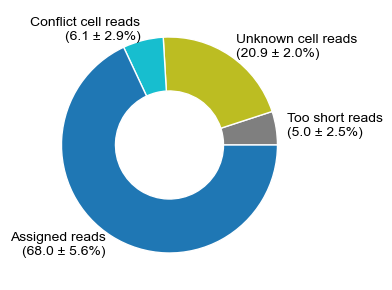

In [128]:
d = pd.read_csv("results/cell_reads_proportion.stats.csv", index_col=0)
ys = d.mean(axis=0).values * 100
stds = d.std(axis=0).values * 100

labels = [
    "Too short reads\n(%.1f ± %.1f%%)" % (ys[0], stds[0]),
    "Unknown cell reads\n(%.1f ± %.1f%%)" % (ys[1], stds[1]),
    "Conflict cell reads\n(%.1f ± %.1f%%)" % (ys[2], stds[2]),
    "Assigned reads\n(%.1f ± %.1f%%)" % (ys[3], stds[3])]

plt.figure(figsize=(4, 3))
plt.pie(ys, radius=1, wedgeprops=dict(width=0.5, edgecolor='w'), 
        # autopct='%1.1f%%', 
        # pctdistance=0.72,
        # startangle=0, 
        colors=["C7", "C8", "C9", "C0"], 
        labels=labels)
plt.tight_layout()
plt.savefig("figures/cell_reads_proportion.pie.pdf")
plt.show()
plt.close()